# 01 — English and Swedish Data Exploration


In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # Mac M1/M2 OpenMP fix

import pandas as pd
import matplotlib.pyplot as plt 

from pathlib import Path
from collections import Counter 

LANGS = ["eng", "swe", "spa"]
DATA_DIR = Path("../data")

### CSV and TSV
+ CSV (Comma-Separeted Values) -> Uses a comma (,) to separate data columns. 
+ TSV (Tab-Separeted Values) -> Uses a tab (\t) character to separate data columns. This in prefered with languague since tabs rarely appear inside standard text fields. 

And for both of them you can use ```pandas.read_csv```!

In [2]:
def load_unimorph(lang: str) -> pd.DataFrame:
    path = DATA_DIR / lang / f"{lang}.tsv" # New syntax for os.path.join()
    df = pd.read_csv(
        path,
        sep="\t",
        names=["lemma", "form", "tags"], 
        quoting=3, 
        dtype=str,
        keep_default_na=False, 
    )
    
    # Drop na values
    n_before = len(df)
    df = df.dropna(subset=["lemma", "form", "tags"])
    n_after = len(df)
    if n_before > n_after: 
        print(f"[{lang}] dropped {n_before - n_after} malformed rows")
    return df

dfs = {lang: load_unimorph(lang) for lang in LANGS}

for lang, df in dfs.items():
    print(f"--- {lang} ---")
    print(df.shape)
    print(df.head(10))
    print()

--- eng ---
(652477, 3)
       lemma         form          tags
0  microtome   microtomes          N;PL
1  microtome   microtomes    V;PRS;3;SG
2  microtome  microtoming  V;V.PTCP;PRS
3  microtome   microtomed         V;PST
4  microtome   microtomed  V;V.PTCP;PST
5        eat         eats    V;PRS;3;SG
6        eat       eating  V;V.PTCP;PRS
7        eat          ate         V;PST
8        eat        eaten  V;V.PTCP;PST
9        eat         eats          N;PL

--- swe ---
(131697, 3)
   lemma      form               tags
0  räkna     räkna         V;NFIN;ACT
1  räkna    räknas        V;NFIN;PASS
2  räkna    räknat        V;V.CVB;ACT
3  räkna   räknats       V;V.CVB;PASS
4  räkna     räkna          V;IMP;ACT
5  räkna    räknar   V;IND;SG;ACT;PRS
6  räkna   räknade   V;IND;SG;ACT;PST
7  räkna    räknas  V;IND;SG;PASS;PRS
8  räkna  räknades  V;IND;SG;PASS;PST
9  räkna     räkna   V;IND;PL;ACT;PRS

--- spa ---
(1196245, 3)
  lemma    form                  tags
0  orar    orar              

# Datasets Basic Stats
Each row represents a specific inflected word form, broken down into three core columns:
*   **`lemma`**: The dictionary or base form of the word (e.g., the infinitive form of a verb or the nominative singular for a noun).
*   **`form`**: The actual surface or inflected form of the word as it appears in text (derived from the lemma).
*   **`tags`**: A semicolon-separated string of morphosyntactic features describing the grammatical properties of the `form` relative to its `lemma`.

## Morphological Tags
The tagsets follow standard linguistic annotation conventions (such as UniMorph) and they vary per language. 

### English
English has a relatively analytic structure with limited inflection, meaning fewer tags are typically required per form. For example:
*   **`V;PRS;3;SG`** $\rightarrow$ **Verb**, **Present** tense, **3rd** person, **Singular** number (e.g., *walks* derived from the lemma *walk*).

### Swedish
Swedish features a richer morphological system with additional categories like mood, voice, and definiteness. For example:
*   **`V;IND;SG;ACT;PRS`** $\rightarrow$ **Verb**, **Indicative** mood, **Singular** number, **Active** voice, **Present** tense (e.g., *gör* derived from the lemma *göra*).

In [3]:
def paradigm_stats(df: pd.DataFrame, lang: str) -> dict:
    stats = {
        "lang": lang,
        "n_rows": len(df),
        "n_unique_lemmas": df["lemma"].nunique(),
        "n_unique_forms": df["form"].nunique(),
        "n_unique_tagsets": df["tags"].nunique(),
        "avg_forms_per_lemma": df.groupby("lemma")["form"].nunique().mean(), 
    } 

    return stats

coverage = pd.DataFrame([paradigm_stats(df, lang) for lang, df in dfs.items()])
print(coverage)

  lang   n_rows  n_unique_lemmas  n_unique_forms  n_unique_tagsets  \
0  eng   652477           399575          579293                10   
1  swe   131697            12520           98413                43   
2  spa  1196245            65059          873866               164   

   avg_forms_per_lemma  
0             1.482593  
1             8.098882  
2            13.753593  


eng: paradigm size stats


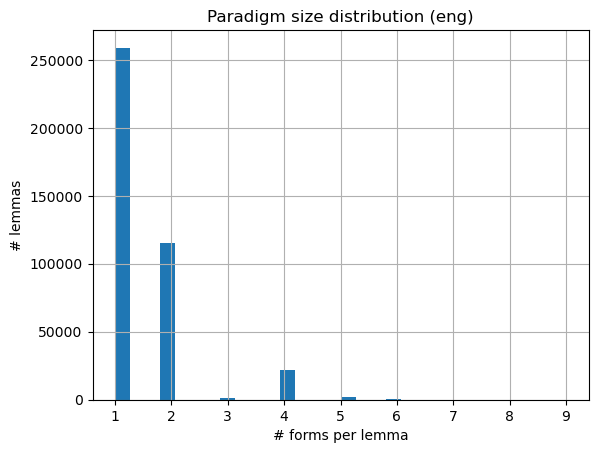

swe: paradigm size stats


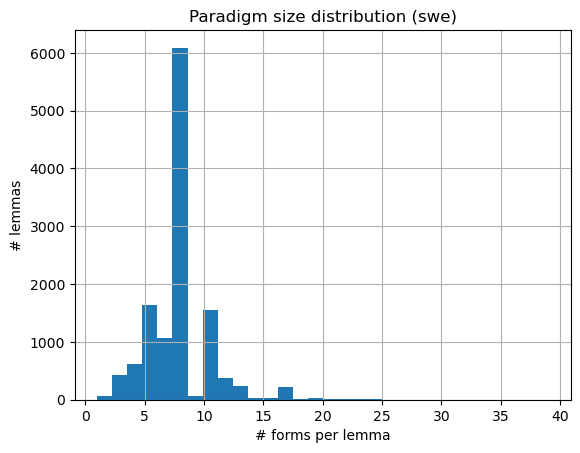

spa: paradigm size stats


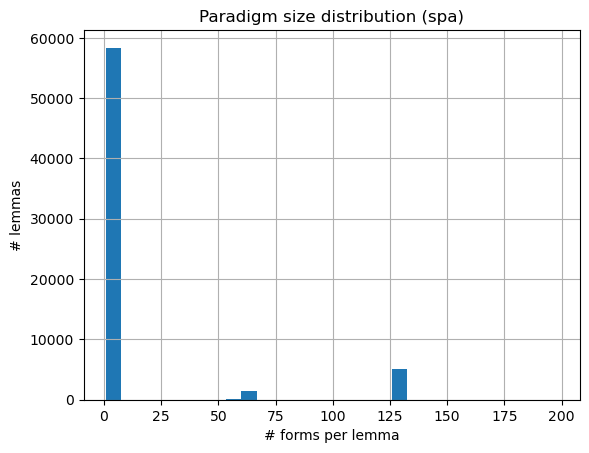

In [4]:
for lang, df in dfs.items():
    paradigm_sizes = df.groupby("lemma")["form"].nunique()
    print(f"{lang}: paradigm size stats")
    
    plt.figure()
    paradigm_sizes.hist(bins=30)
    plt.title(f"Paradigm size distribution ({lang})")
    plt.xlabel("# forms per lemma")
    plt.ylabel("# lemmas")
    plt.show()

In [5]:
# Most frequent individual tags (split tag bundles on ';')

def tag_frequency(df: pd.DataFrame) -> Counter: 
    counter = Counter()
    for tagset in df["tags"]:
       counter.update(tagset.split(";")) 
    return counter

for lang, df in dfs.items():
    freq = tag_frequency(df)
    print(f"--- {lang} top 10 individual tags ---")
    for tag, count in freq.most_common(10):
        print(f"{tag:10s} {count}")
    print()

--- eng top 10 individual tags ---
N          388563
SG         287165
ADJ        136400
V          127514
PL         125314
PRS        47834
V.PTCP     47834
PST        47832
NFIN       31848
IMP+SBJV   31848

--- swe top 10 individual tags ---
N          66778
SG         54708
PL         50270
V          46451
INDF       44452
DEF        40794
NOM        33389
GEN        33389
ACT        23541
IND        19732

--- spa top 10 individual tags ---
V          1048576
PL         755476
SG         737908
2          586995
PRO        496677
3          400713
IMP        384646
1          330982
ACC        284585
INFM       231700



### Observation
1. English has way more lemmas than the other two languagues (400k). This is because the English edition of Wiktionary is by far the largest and most thoroughly crowdsourced dictionary database in existence. It includes hundreds of thousands of entries for obscure words, archaic terms, technical jargon, proper nouns, and borrowed words.
2. In this dataset we have both nouns and verbs. Maybe we should filter out just the verbs. 

# Tokenization 

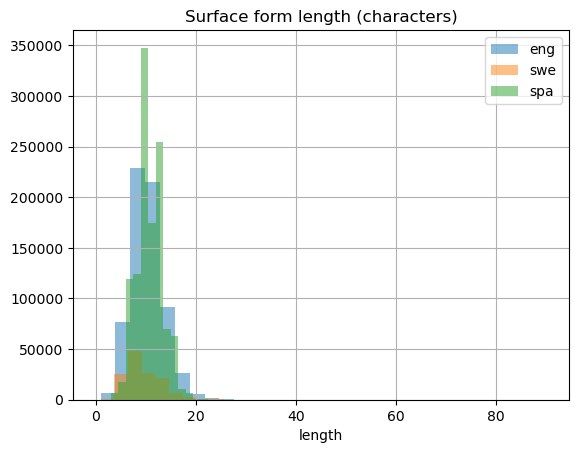

: 

In [ ]:
# Character Lenght

for lang, df in dfs.items():
    df["form_len_chars"] = df["form"].str.len()
    
plt.figure()
for lang, df in dfs.items():
    df["form_len_chars"].hist(bins=30, alpha=0.5, label=lang)
plt.legend()
plt.title("Surface form length (characters)")
plt.xlabel("length")
plt.show()

In [ ]:
# Token length

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("google/mt5-small")

for lang, df in dfs.items():
    df["form_len_tokens"] = df["form"].apply(lambda f: len(tokenizer.tokenize(f)))
    
plt.figure()
for lang, df in dfs.items():
    df["form_len_tokens"].hist(bins=20, alpha=0.5, label=lang)
plt.legend()
plt.title("Surface form length (subword tokens)")
plt.xlabel("# tokens")
plt.show()


/Users/falcolluc/miniconda3/envs/lora/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
